Implicit Neural Representation-Based fMRI Reconstruction:

1. fMRI Data Simulation
2. Prior Image Generation
3. Prior Embedding
4. fMRI Reconstruction


In [1]:
# import relevant modules

from snake.core import NufftAcquisitionEngine
from snake.core.handlers import BlockActivationHandler
from snake.core.phantom import Phantom
from snake.core.simulation import SimConfig, default_hardware, GreConfig
from snake.core.transform import apply_affine
from snake.mrd_utils import NonCartesianFrameDataLoader
from snake.toolkit.reconstructors import SequentialReconstructor
import numpy as np
import yaml
import os
import sys

current_dir = os.getcwd() 
project_root = os.path.dirname(current_dir)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

from utilis.utilis_plot import plot_ts_roi
import torch
from snake.toolkit.plotting import axis3dcut
from mrinufft.trajectories.display import display_3D_trajectory, display_2D_trajectory
from snake.core.sampling.samplers import LoadMultiTrajectorySampler
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure
import tinycudann as tcnn

# For reconstruction
import cupy as cp
import matplotlib.pyplot as plt
import mrinufft
from mrinufft import get_operator
from tqdm.auto import tqdm
import logging

logging.getLogger("snake").setLevel(level=logging.DEBUG)

In [2]:
# fMRI Data Simulation--Spiral3DT_Caini
# Configuration for Acquisition, Phantom, and Diagamram

sim_idx = 'Simulation_Mar16_RotatedSpiral'
os.makedirs(f'dataset/sim3DT/{sim_idx}', exist_ok=True)

sim_conf = SimConfig(
    max_sim_time=240,
    seq=GreConfig(TR=50, TE=30, FA=12),
    hardware=default_hardware,
)

# frame_num = sim_conf.max_sim_time * 1000 // sim_conf.seq.TR

sim_conf.hardware.n_coils = 1  # Update to get multi coil results.
sim_conf.hardware.field_strength = 3
sim_conf.fov.res_mm = (3, 3, 3)  # 1 mm isotropic resolution
sim_conf.fov.size = (192, 192, 120)  # Single slice  (in mm)
sim_conf.fov.offset = (-90, -110, -40)  # Located in the center of the cortex
sim_conf.fov.angles = (0, 0, 0) #
img_shape = sim_conf.fov.shape

activation_handler = BlockActivationHandler(
    block_off=20,
    block_on=20,
    duration=240,
    atlas="hardvard-oxford__cort-maxprob-thr0-1mm",
    atlas_label=48,  # occipital cortex
)

from mrinufft.io import read_trajectory

filename = "/volatile/home/cp279020/traj_240s/stackofspiral_dynamic_r2_18_proj_smax0.2_192x192x120_240s.bin"
traj = read_trajectory(
    grad_filename=filename,
    dwell_time=0.002,
    raster_time= 0.01,
)

np.save(f"dataset/sim3DT/{sim_idx}/traj.npy", traj[0].reshape(4800,1,15000, 3))

sampler = LoadMultiTrajectorySampler(
    path=f"dataset/sim3DT/{sim_idx}/traj.npy",
)

shots_per_frame = 20

engine_t2s = NufftAcquisitionEngine(
    model="T2s", # "T2s" or "simple", simple here to ignore T2* decay
    snr=1000,
    slice_2d=False,  # Does not matter, we are in 2D anyway (:
)

phantom_original = Phantom.from_brainweb(
    sub_id=4, sim_conf=sim_conf, tissue_file="tissue_3T", output_res=1
)
phantom = phantom_original.resample(
    new_affine=sim_conf.fov.affine, new_shape=sim_conf.fov.shape, use_gpu=True
)  # select phantom and resample to desired FOV

No matrix size found in the header. The header is probably missing.


[fetch_atlas_harvard_oxford] Dataset found in /home/ql284910/nilearn_data/fsl


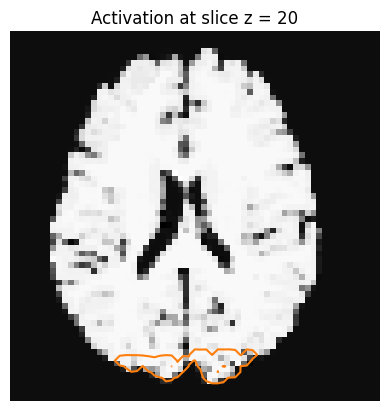

/home/ql284910/data/Env_INR/lib/python3.10/site-packages/xsdata/formats/dataclass/parsers/utils.py:130: ConverterWarning: Failed to convert value for `waveformInformationType.waveformType`
  `2043` is not a valid `waveformInformationTypeWaveformType`
  warnings.warn(message, ConverterWarning)


After reshaping - Traj: (4800, 1, 15000, 3), Kspace: (4800, 1, 1, 15000)


In [3]:
# Generate the simulation data based on the Caini experimental setting

example_phantom = activation_handler.get_static(phantom.copy(), sim_conf)

roi = example_phantom.masks[example_phantom.labels_idx["ROI"]]

roi_resampled = apply_affine(
    roi,
    new_affine=sim_conf.fov.affine,
    old_affine=phantom.affine,
    new_shape=sim_conf.fov.shape,
)

# +

contrast = phantom.contrast(sim_conf=sim_conf)

# verts, faces, _, _ = measure.marching_cubes(contrast, level=contrast.mean())

z = contrast.shape[2] // 2  # middle slice index

plt.imshow(contrast[:, :, z].T, origin='lower', cmap='gray')
plt.contour(roi_resampled[:, :, z].T, levels=[0.05], colors='tab:orange', origin='lower')
plt.axis('off')
plt.title(f"Activation at slice z = {z}")
plt.show()

# fig = plt.figure(figsize=(8, 8))
# ax = fig.add_subplot(111, projection='3d')
# mesh = Poly3DCollection(verts[faces], alpha=0.7)
# mesh.set_facecolor([0.5, 0.5, 1])
# ax.add_collection3d(mesh)
# ax.set_xlim(0, contrast.shape[0])
# ax.set_ylim(0, contrast.shape[1])
# ax.set_zlim(0, contrast.shape[2])
# plt.title('3D iso-surface of contrast')
# plt.show()

# engine_t2s(   # save the k-space data to specified file
#     f"dataset/sim3DT/{sim_idx}/dataloader.mrd",
#     sampler,
#     phantom,
#     sim_conf,
#     handlers=[activation_handler],
#     worker_chunk_size=20,
#     n_workers=1,
#     nufft_backend="gpunufft",
# )

all_trajs = []
all_kspaces = []
with NonCartesianFrameDataLoader(f"dataset/sim3DT/{sim_idx}/dataloader.mrd", squeeze_dims=True) as data_loader:
    for _, traj, kspace_data in data_loader.iter_frames(shot_dim=True):
        all_trajs.append(torch.from_numpy(np.asarray(traj)).float())
        all_kspaces.append(torch.from_numpy(np.ascontiguousarray(kspace_data)).to(torch.complex64)) 
    shape = data_loader.shape
    nb_coils = data_loader.n_coils
    smaps = data_loader.get_smaps(resample=False)
    dyn_datas = data_loader.get_all_dynamic()

# Convert lists to PyTorch tensors and adjust dimensions for 2D setting
all_trajs = torch.stack(all_trajs)  # [frame, sample_point, location] 
# if nb_coils == 1:
#     all_kspaces = torch.stack(all_kspaces)[:,0,0,:] # [frame, sample_point] 
# else:
#     all_kspaces = torch.stack(all_kspaces)[:,:,0,:] # [frame, sample_point] 

all_trajs_np = all_trajs.numpy()
all_kspaces_np = torch.stack(all_kspaces).numpy()

print(f"After reshaping - Traj: {all_trajs_np.shape}, Kspace: {all_kspaces_np.shape}")

# if smaps is not None:
#     smaps_np = smaps
#     np.save(f'dataset/sim3DT/{sim_idx}/smaps.np', smaps_np)   

num_frame = int(all_trajs_np.shape[0]/shots_per_frame)
samples_per_shot = all_trajs_np.shape[2]
# np.save(f"dataset/sim3DT/{sim_idx}/roi.npy", roi_resampled)
# np.save(f'dataset/sim3DT/{sim_idx}/traj', all_trajs_np.reshape(num_frame, shots_per_frame, samples_per_shot, 3))    # # [frame, shots_per_frame, sample_point, location]
# np.save(f'dataset/sim3DT/{sim_idx}/kspace', all_kspaces_np.reshape(num_frame, nb_coils, shots_per_frame, samples_per_shot))    

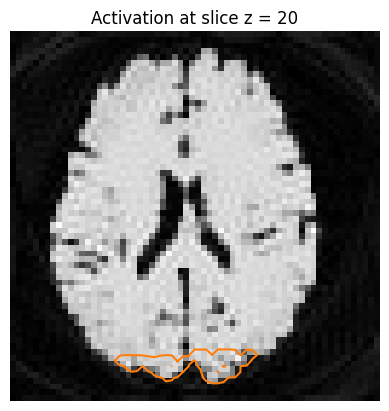

Reconstruction_averafed shape: (64, 64, 40, 2)


In [ ]:
# 2. i_bg reconstruction

from mrinufft.extras.optim import loss_l2_reg

# Get the accumulated single-coil k-space and stacked trajectory.
# For a single-coil static background solve, k-space should be [n_coils, total_samples]
# and samples should be [total_samples, 3]. Using [1, total_samples, 3] for samples can
# change operator conventions and lead to a mis-scaled / mis-phased background image.
coil_num = all_kspaces_np.shape[1]
samples_per_frame = samples_per_shot * shots_per_frame

Kspace_acculumulted = all_kspaces_np.reshape(coil_num, samples_per_frame * num_frame).astype(np.complex64)
traj_stacked = all_trajs_np.reshape(samples_per_frame * num_frame, 3).astype(np.float32)

kwargs = dict(shape=img_shape, n_coils=coil_num, density=True, smaps=smaps)
nufft_operator_average = get_operator('cufinufft')(samples=traj_stacked, **kwargs)

recon_dict = nufft_operator_average.pinv_solver(
        Kspace_acculumulted, optim="cg", max_iter=25, callback=loss_l2_reg
    )   # recon_average shape: (x,y,z)

print(f"CG loss: {recon_dict[1]}")
recon_bg = recon_dict[0][0,0]
z = contrast.shape[2] // 2  # middle slice index
plt.imshow(np.abs(recon_bg[:, :, z].T), origin='lower', cmap='gray')
plt.contour(roi_resampled[:, :, z].T, levels=[0.05], colors='tab:orange', origin='lower')
plt.axis('off')
plt.title(f"Activation at slice z = {z}")
plt.show()

recon_bg_np = np.stack([recon_bg.real, recon_bg.imag], axis=-1)
print(f"Reconstruction_averafed shape: {recon_bg_np.shape}")

np.save(f'dataset/sim3DT/{sim_idx}/averagedBG.npy', recon_bg_np.astype(np.float32))   # (x, y, z, 2), save one frame

In [ ]:
print(recon_bg_np[...,0].mean(), recon_bg_np[...,1].mean())

0.01803777 -3.1637865e-06


In [ ]:
# 2. i_bg reconstruction

from mrinufft.extras.optim import loss_l2_reg

# Get the accumulated single-coil k-space and stacked trajectory.
# For a single-coil static background solve, k-space should be [n_coils, total_samples]
# and samples should be [total_samples, 3]. Using [1, total_samples, 3] for samples can
# change operator conventions and lead to a mis-scaled / mis-phased background image.
coil_num = all_kspaces_np.shape[1]
samples_per_frame = samples_per_shot * shots_per_frame

Kspace_acculumulted = all_kspaces_np.reshape(coil_num, samples_per_frame * num_frame).astype(np.complex64)
traj_stacked = all_trajs_np.reshape(samples_per_frame * num_frame, 3).astype(np.float32)

kwargs = dict(shape=img_shape, n_coils=coil_num, density=True, smaps=smaps)
nufft_operator_average = get_operator('cufinufft')(samples=traj_stacked, **kwargs)

recon_dict = nufft_operator_average.pinv_solver(
        Kspace_acculumulted, optim="cg", max_iter=25, callback=loss_l2_reg
    )   # recon_average shape: (x,y,z)

print(f"CG loss: {recon_dict[1]}")
recon_bg = recon_dict[0]
z = contrast.shape[2] // 2  # middle slice index
plt.imshow(np.abs(recon_bg[:, :, z].T), origin='lower', cmap='gray')
plt.contour(roi_resampled[:, :, z].T, levels=[0.05], colors='tab:orange', origin='lower')
plt.axis('off')
plt.title(f"Activation at slice z = {z}")
plt.show()

recon_bg_np = np.stack([recon_bg.real, recon_bg.imag], axis=-1)
print(f"Reconstruction_averafed shape: {recon_bg_np.shape}")

np.save(f'dataset/sim3DT/{sim_idx}/averagedBG.npy', recon_bg_np.astype(np.float32))   # (x, y, z, 2), save one frame


In [11]:
# NUFFT reconstruction

# Get the average k-space, trajectory and reconstruction
kspace_nufft = all_kspaces_np.reshape(num_frame, coil_num, samples_per_frame)  # (slice, 1, sample)
traj_nufft = all_trajs_np.reshape(num_frame, samples_per_frame,3)  # (1, sample, location)

kwargs = dict(shape=img_shape,n_coils=coil_num,density=True,smaps=smaps)
nufft_operator = get_operator('cufinufft',samples=traj_nufft[0],**kwargs)
recon_nufft = []
for i in tqdm(range(num_frame)):
    nufft_operator.samples = traj_nufft[i]
    recon_nufft.append(nufft_operator.adj_op(kspace_nufft[i])[0,0,:,:,:])
recon_nufft_np = np.stack(recon_nufft, axis=0)  # (frame, x, y, z, 2)
print(f"NUFFT recon shape: {recon_nufft_np.shape}")
np.save(os.path.join(f"dataset/sim3DT/{sim_idx}/", "NUFFT_recon.npy"), recon_nufft_np)

/home/ql284910/data/mri-nufft/src/mrinufft/_utils.py:67: UserWarning: Samples will be rescaled to [-pi, pi), assuming they were in [-0.5, 0.5)
  warnings.warn(
/home/ql284910/data/mri-nufft/src/mrinufft/_utils.py:72: UserWarning: Samples will be rescaled to [-0.5, 0.5), assuming they were in [-pi, pi)
  warnings.warn(


  0%|          | 0/240 [00:00<?, ?it/s]

NUFFT recon shape: (240, 64, 64, 40)


In [ ]:
# # Normalization is necessary when represente whole subject w/o statics/dynamics sepeparation
# # (no need for this when using proposed method)
# rescaling = False

# if rescaling:
#     norm_method = 'minmax'

#     recon = recon_average_np  # variable available in notebook
#     assert recon.ndim == 4 and recon.shape[-1] == 2, "Expecting shape (T,H,W,2)"

#     if norm_method == 'per_channel_std':
#         means = recon.mean(axis=(0,1,2))          # shape (2,)
#         stds = recon.std(axis=(0,1,2))
#         recon_scaled = (recon - means) / (stds + 1e-8)
#         stats = dict(method=norm_method, means=means, stds=stds)
#     elif norm_method == 'minmax':
#         mins = recon.min(axis=(0,1,2))
#         maxs = recon.max(axis=(0,1,2))
#         mids = (maxs + mins) / 2.0
#         half = (maxs - mins) / 2.0 + 1e-8
#         recon_scaled = (recon - mids) / half
#         stats = dict(mins=mins, maxs=maxs)
#     elif norm_method == 'global_maxabs':
#         maxabs = np.abs(recon).max()
#         recon_scaled = recon / (maxabs + 1e-8)
#         stats = dict(method=norm_method, maxabs=maxabs)
#     elif norm_method == 'simple':
#         max = recon.max(axis=(0,1,2))
#         recon_scaled = recon / max
#         stats = dict(max=max)
#     else:
#         raise ValueError(f"Unknown norm_method: {norm_method}")

#     # Print ranges before / after to verify
#     print("Before scaling:")
#     print("  Real: min={:.6f}, max={:.6f}".format(recon[...,0].min(), recon[...,0].max()))
#     print("  Imag: min={:.6f}, max={:.6f}".format(recon[...,1].min(), recon[...,1].max()))
#     print("\nAfter scaling:")
#     print("  Real: min={:.6f}, max={:.6f}".format(recon_scaled[...,0].min(), recon_scaled[...,0].max()))
#     print("  Imag: min={:.6f}, max={:.6f}".format(recon_scaled[...,1].min(), recon_scaled[...,1].max()))

#     # Save scaled data and stats for later use (and reproducibility)
#     np.save(f'dataset/sim3DT/{sim_idx}/averagedRecon_scaled.npy', recon_scaled.astype(np.float32)) # (frame, H, W, 2), same for every frame
#     np.savez(f'dataset/sim3DT/{sim_idx}/scaling_stats.npz', **stats)
#     np.save(f'dataset/sim3DT/{sim_idx}/averagedRecon_scaled_slice.npy', recon_scaled[0].astype(np.float32))   # (H, W, 2), save one frame
# else:
#     np.save(f'dataset/sim3DT/{sim_idx}/averagedBG.npy', recon_average_np.astype(np.float32))   # (x, y, z, 2), save one frame

0.018706217


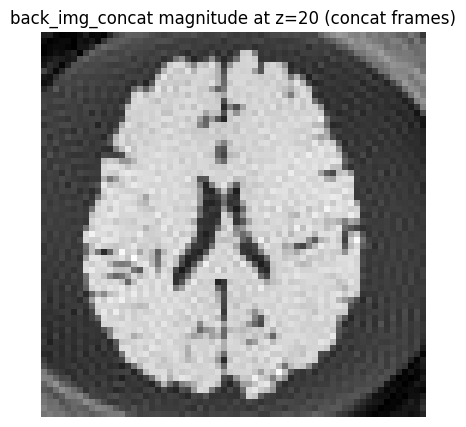

/home/ql284910/data/pysap-fmri/src/fmri/reconstructors/base.py:51: UserWarning: The in space regulariser is not set. Setting to identity. Note that optimization is just a gradient descent in space
  warnings.warn(
/home/ql284910/data/pysap-fmri/src/fmri/reconstructors/base.py:60: UserWarning: The in-time regularizer is not set. Setting to identity. Note that frame will be reconstruct independently.
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/240 [00:00<?, ?it/s]

In [12]:
# Global CG Reconstruction

# 1) Concatenate k-space across frames:
# kspace_frames: (n_frame, n_coil, n_sample) -> (n_coil, n_frame*n_sample)
kspace_frames = all_kspaces_np.reshape(num_frame, nb_coils, shots_per_frame, samples_per_shot).reshape(num_frame,nb_coils,shots_per_frame*samples_per_shot)
traj3d = all_trajs_np.reshape(num_frame, shots_per_frame, samples_per_shot, 3).reshape(num_frame, shots_per_frame*samples_per_shot, 3)

n_frame, n_coil, n_sample = kspace_frames.shape
kspace_all = np.transpose(kspace_frames, (1, 0, 2)).reshape(n_coil, -1)  # (n_coil, n_frame*n_sample)

# 2) Concatenate trajectory across frames to match kspace_all:
# traj3d: (n_frame, n_sample, 3) -> (n_frame*n_sample, 3)
samples_all = traj3d.reshape(-1, traj3d.shape[-1]).astype(np.float32)

logging.info(f"[BG] kspace_all  : {kspace_all.shape} dtype={kspace_all.dtype}")
logging.info(f"[BG] samples_all : {samples_all.shape} dtype={samples_all.dtype}")

# 4) Build NUFFT operator for concatenated samples

kwargs0 = dict(shape=img_shape, n_coils=kspace_all.shape[0], density=True, smaps=smaps)
nufft_operator0 = get_operator("cufinufft")(samples=samples_all, **kwargs0)
x0 = nufft_operator0.adj_op(kspace_all)
print(np.abs(x0).mean())

z = img_shape[2] // 2
plt.figure(figsize=(5, 5))
plt.imshow(np.abs(x0[0,0,:, :, z].T), origin="lower", cmap="gray")
plt.title(f"back_img_concat magnitude at z={z} (concat frames)")
plt.axis("off")
plt.show()

# 5) Global CG reconstruction

from fmri.reconstructors import ConjugateGradientReconstructor
from modopt.opt.linear import Identity

kwargs = dict(shape=img_shape, n_coils=kspace_all.shape[0], density=True, smaps=smaps)
nufft_operator_cg = get_operator("cufinufft")(samples=traj3d[0], **kwargs)

reconstructor = ConjugateGradientReconstructor(fourier_op=nufft_operator_cg,
                                               space_linear_op=Identity,
                                               progbar_disable=True)

recon_cg = reconstructor.reconstruct(kspace_data=np.ascontiguousarray(kspace_frames),
                                     restart_strategy="cold",
                                     traj_dynamic = traj3d,
                                     compute_backend='numpy',
                                     optim = "lsqr",
                                     x_init = x0
                                    )

np.save(os.path.join(f"dataset/sim3DT/{sim_idx}/", "Global_CG.npy"), recon_cg)

In [ ]:
# it's not recommended to run 3D+T reconstruction in jupyter
# recommend to run dynamic_Recon3D.py instead

USE_YAML = False  # choose to use yaml config or config here

if USE_YAML:
    with open('./configs/Prior_Embedding.yaml', 'r') as f:
        config = yaml.load(f, Loader=yaml.FullLoader)
else:
    config = {

        # =======================
        # Logger options
        # =======================
        "log_iter": 10,
        "val_iter": 100,
        "image_save_iter": 100,
        "display_image_num": 8,
        "log_interval": 10,
        "hist_interval": 0,
        "save_interval": 200,

        # =======================
        # Optimization options
        # =======================
        "max_iter": 5000,
        "batch_size": 20,
        "loss": "Complex_L2",
        "optimizer": "Adam",
        "amp": True,
        "grad_clip": 0.0,
        "weight_decay": 0.0,
        "beta1": 0.9,
        "beta2": 0.999,
        "lr": 1e-4,

        # =======================
        # Encoder options
        # =======================
        "encoder": "SpatioTemporal_Encoder",

        "Position_encoder": {
            "embedding": "gauss",
            "scale": 4,
            "embedding_size": 128,
            "coordinates_size": 4,
        },

        "SpatioTemporal_Encoder": {
            "spatial_embedding": "randn",
            "temporal_embedding": "gauss",
            "scale_spatial": 4,
            "scale_temporal": 3,
            "embedding_size_spatial": 256,
            "embedding_size_temporal": 64,
            "coordinates_size_spatial": 3,
            "coordinates_size_temporal": 1,
            "learnable_temporal": False,
        },

        # =======================
        # Model options
        # =======================
        "model": "SIREN",
        "net": {
            "network_input_size": 640,
            "network_output_size": 2,
            "network_depth": 4,
            "network_width": 256,
        },

        # =======================
        # Data config
        # =======================
        "img_size": [160, 64, 64, 40, 2],
        "pretrain": False,
        "output_path": ".",
        "exp_idx": "exp2_nov18",
    }


In [ ]:
# # reconstruction
# # it's not recommended to run 3D+T reconstruction in jupyter
# # recommend to run dynamic_Recon3D.py instead

# from dynamic_Recon3D import dynamic_Recon3D

# kspaces = np.load(f'/home/ql284910/data/INR-fMRI/dataset/sim3DT/{sim_idx}/kspace.npy')  # (150, 10000)-complex
# trajs = np.load(f'/home/ql284910/data/INR-fMRI/dataset/sim3DT/{sim_idx}/traj.npy')  # (150, 10000, 3)
# back_img = np.load(f'/home/ql284910/data/INR-fMRI/dataset/sim3DT/{sim_idx}/averagedBG.npy')  # (x, y, z, 2)
# csm = np.load(f'/home/ql284910/data/INR-fMRI/dataset/sim3DT/{sim_idx}/csm.npy') if kspaces.shape[1]>1 else None  # (coil, H, W, 2)
# kspace3d = kspaces.reshape(kspaces.shape[0], kspaces.shape[1], kspaces.shape[2]*kspaces.shape[3])  # (time, coil, sample_point)
# traj3d = trajs.reshape(trajs.shape[0], trajs.shape[1]*trajs.shape[2],trajs.shape[3])  # (time, sample_point, location)
# print(kspace3d.shape, traj3d.shape)
# dynamic_Recon3D(kspace3d, traj3d, back_img, config, device=torch.device("cuda:0"), case_name=sim_idx, csm=csm)


In [13]:
with NonCartesianFrameDataLoader(f"dataset/sim3DT/{sim_idx}/dataloader.mrd") as data_loader:
    sim_conf = data_loader.get_sim_conf()
    dyn_datas = data_loader.get_all_dynamic()
    threshold = 0.05 
    phantom = data_loader.get_phantom()
    roi = phantom.masks[phantom.labels == "ROI"].squeeze()
    roi_thresh = roi > threshold
    roi_resampled = apply_affine(roi, new_affine=sim_conf.fov.affine, old_affine=phantom.affine,new_shape=sim_conf.fov.shape)
    kwargs = {
        "activation_handler": activation_handler,
        "dyn_datas": dyn_datas,
        "sim_conf": sim_conf,
        "roi_resampled": roi_resampled,
    }

/home/ql284910/data/Env_INR/lib/python3.10/site-packages/xsdata/formats/dataclass/parsers/utils.py:130: ConverterWarning: Failed to convert value for `waveformInformationType.waveformType`
  `2043` is not a valid `waveformInformationTypeWaveformType`
  warnings.warn(message, ConverterWarning)


In [45]:
img_BG = np.load(f'dataset/sim3DT/{sim_idx}/averagedBG.npy')

# recon_cplx = 0.0005*(np.load(f'/volatile/home/ql284910/data/INR-fMRI/outputs/NeRP3D_ourputs/seq_outputs_xyz_only/Spiral3DT_Caini_R2_case2_feb19_exp2/recon_all_ri.npy').reshape((num_frame, img_shape[0], img_shape[1], img_shape[2], 2)))

recon_cplx = img_BG + 0.0005*(np.load(f'/volatile/home/ql284910/data/INR-fMRI/outputs/dynamic_Recon3DTrue/Spiral3DT_Caini_R2_case2/feb19_exp1_640_512_3_lr5e-06_bs4_SpatioTemporal_Encoder/images/reconstruction_820.npy').reshape((num_frame, img_shape[0], img_shape[1], img_shape[2], 2)))

DEBUG:snake.toolkit.analysis.stats:image_=(240, 163840), design matrix=(240, 2)


recon.shape: (240, 64, 64, 40) dtype: float32
activation-block_on
(13, 6, 34)
[None] TSNR: 55.371582


/home/ql284910/data/snake-fmri/src/snake/toolkit/analysis/stats.py:53: DeprecationWarning: The parameter "contrast_type" will be removed in 0.13.0 release of Nilearn. Please use the parameter "stat_type" instead.
  contrast = compute_contrast(labels, results, con_val, contrast_type="t")


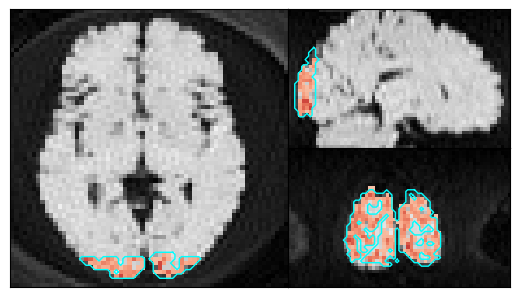

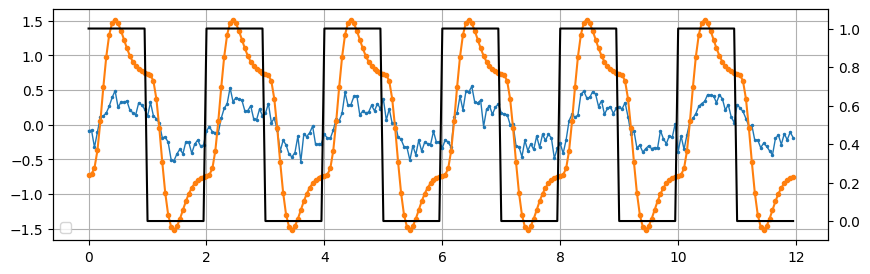

In [ ]:
# Visualizing the Reconstructed results---proposed

from utilis.utilis_plot import plot_activation_3d, cal_z_score, cluster_threshold_3d

# recon_proposed = np.sqrt(recon_cplx[..., 0].astype(np.float32)**2 + recon_cplx[..., 1].astype(np.float32)**2)

recon_proposed = np.abs(recon_cg)

print("recon.shape:", recon_proposed.shape, "dtype:", recon_proposed.dtype)

threshold = 0.05
z_score, stats_results = cal_z_score(recon_proposed, threshold=threshold, TR=1, **kwargs)

filtered, info = cluster_threshold_3d(act = z_score, 
               voxel_thresh = 3, 
               min_cluster_size=100, 
               connectivity=6, 
               two_sided = False,
               use_abs=False, 
               return_labels=False)

plot_activation_3d(recon_proposed, 
                filtered.T, 
                threshold, 
                width_inches=5, 
                cbar=False, 
                n_cols=1, 
                roi_resampled=roi_resampled,
                thresh=3),

# recon_mag = np.sqrt(recon_cplx[..., 0].astype(np.float32)**2 + recon_cplx[..., 1].astype(np.float32)**2)

recon_mag = np.abs(recon_cg)

TR = sim_conf.seq.TR / 1000

activation_event = dyn_datas[0].data[1].reshape(240, 20).mean(axis=1)
expected_signal = dyn_datas[0].data[0].reshape(240, 20).mean(axis=1)
num_frames = len(recon_proposed)  
resampled_event = activation_event[:num_frames].reshape(num_frames, -1).mean(axis=1)
resampled_signal = expected_signal[:num_frames].reshape(num_frames, -1).mean(axis=1)
resampled_signal = (resampled_signal - resampled_signal.mean()) / resampled_signal.std()
time_samples = np.arange(len(recon_proposed)) * TR 
threshold = 0.05
roi_thresh= roi_resampled > threshold 
fig, ax = plt.subplots(figsize=(10, 3))
_, ts, _ = plot_ts_roi(
        recon_proposed[:,:,:,z], roi_thresh[:,:,z], None, TR, ax, center=True
        # , label="Reconstructed"
    )
ax2 = ax.twinx()
ax2.plot(time_samples, resampled_event, 
        #  label="Activation", 
         color="black")
# ax2.set_ylabel("Activation Event (0-1)")
ax2.set_ylim(0-0.1, 1+0.1)
ax2.tick_params(axis='y')
marker_indices = np.linspace(0, num_frames - 1, num_frames, dtype=int)
ax.plot(time_samples, resampled_signal, marker='o', markersize=3, markevery=marker_indices, 
        # label="Expected"
        )
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="lower left") 
ax.grid()
plt.show()